# Calculating regional tsunami travel times, a Cascadia example

Ray-traced tsunami travel times for a hypothetical megathrust rupture on the
Cascadia subduction zone, offshore Washington state.

**Source:** 47.86°N, 124.91°W — consistent with the locked zone of the Cascadia megathrust.

**Bathymetry:** GEBCO-derived 30 arc-second grid (`data/cascadia.xyz`).

> **Note:** this notebook requires `scipy` and `pandas` in addition to the core
> TsunamiTrace dependencies.  Install with `pip install scipy pandas`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.interpolate import griddata, RegularGridInterpolator
from scipy.stats import binned_statistic_2d
import TsunamiTrace as tt
%matplotlib inline

## Load bathymetry

The xyz file is a regular 1/120° (30 arc-second) grid stored row-by-row
(latitude outer, longitude inner).  We reshape it directly into a 2-D array.

In [2]:
print('Loading data/cascadia.xyz …', end='', flush=True)
df = pd.read_csv(
    '../data/cascadia.xyz',
    comment='#', sep=r'\s+', header=None,
    names=['lon', 'lat', 'depth'], engine='c',
)
print(f' {len(df):,} points')

# Grid axes (sorted ascending)
lon_full = np.sort(df.lon.unique())
lat_full = np.sort(df.lat.unique())
n_lon    = len(lon_full)
n_lat    = len(lat_full)

print(f'Grid   : {n_lon} \u00d7 {n_lat}  '
      f'(spacing {lon_full[1]-lon_full[0]:.4f}\u00b0)')
print(f'Lon    : {lon_full[0]:.3f} \u2013 {lon_full[-1]:.3f}\u00b0')
print(f'Lat    : {lat_full[0]:.3f} \u2013 {lat_full[-1]:.3f}\u00b0')
print(f'Depth  : {df.depth.min():.0f} \u2013 {df.depth.max():.0f} m  '
      f'(negative = ocean)')

# Reshape into (n_lat, n_lon) — lat is the slow (row) axis
depth_grid = (
    df.sort_values(['lat', 'lon'])['depth']
    .values
    .reshape(n_lat, n_lon)
)

# trace_rays expects positive depth (ocean) and shape (n_lon, n_lat)
lon_arr       = lon_full
lat_arr       = lat_full
depth_tracing = np.where(depth_grid < 0, -depth_grid, 0.0).T

print(f'\nRay-tracing grid: {len(lon_full)} \u00d7 {len(lat_full)}')

Loading data/cascadia.xyz … 1,684,800 points
Grid   : 1080 × 1560  (spacing 0.0083°)
Lon    : -131.996 – -123.004°
Lat    : 39.004 – 51.996°
Depth  : -5191 – 3531 m  (negative = ocean)

Ray-tracing grid: 1080 × 1560


## Bathymetry and topography, plot to check it looks good

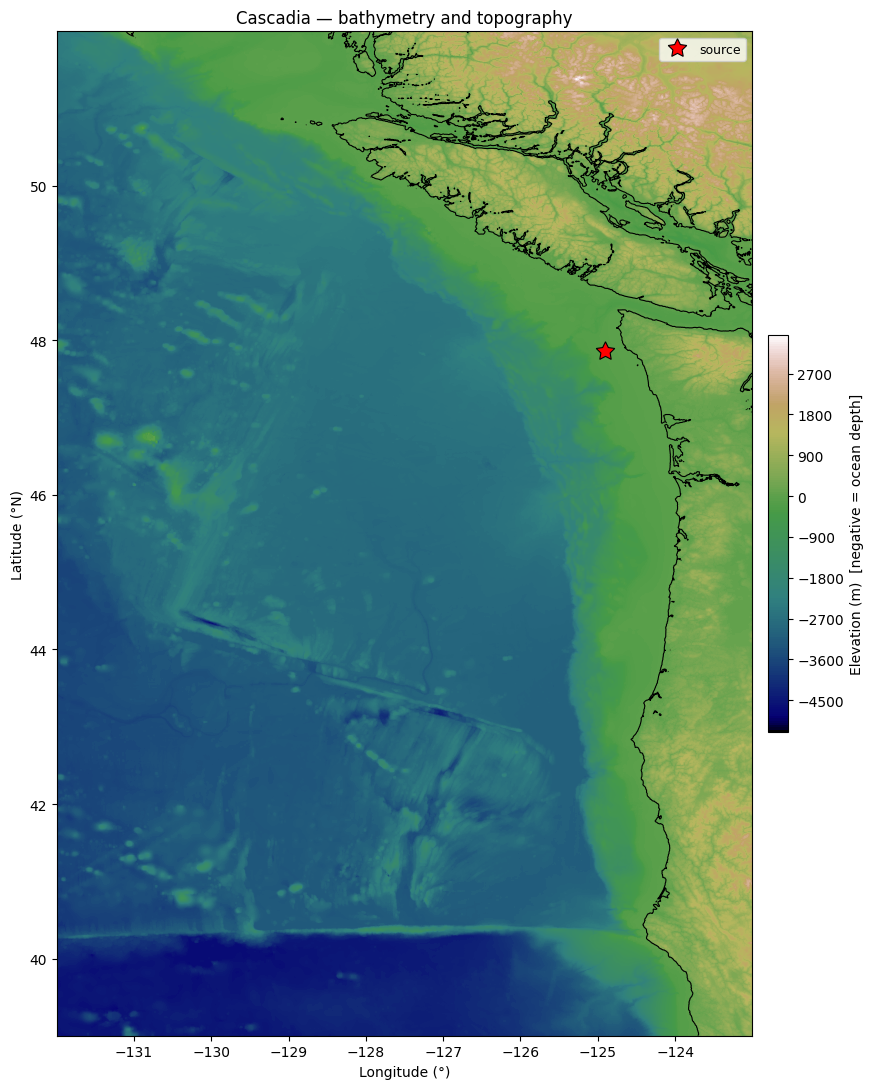

In [3]:
SOURCE_LON = -124.91
SOURCE_LAT =   47.86

vmin = float(np.nanmin(depth_grid))
vmax = float(np.nanmax(depth_grid))
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=max(vmax, 1))

fig, ax = plt.subplots(figsize=(9, 11))

cf = ax.contourf(lon_full, lat_full, depth_grid,
                 levels=200, cmap='gist_earth', norm=norm)

# Coastline at sea level
ax.contour(lon_full, lat_full, depth_grid,
           levels=[0], colors='k', linewidths=0.8)

# Source
ax.plot(SOURCE_LON, SOURCE_LAT,
        marker=(5, 1), markersize=14,
        markerfacecolor='red', markeredgecolor='k', markeredgewidth=0.8,
        linestyle='none', zorder=6, label='source')

ax.set_xlabel('Longitude (\u00b0)')
ax.set_ylabel('Latitude (\u00b0N)')
ax.set_title('Cascadia \u2014 bathymetry and topography')
ax.set_aspect('equal')
ax.legend(fontsize=9)

cbar = fig.colorbar(cf, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label('Elevation (m)  [negative = ocean depth]')
plt.tight_layout()
plt.show()

## Tsunami ray tracing

Fan rays at 0.0005° azimuth spacing from the source and integrate for 3 hours.
The dense ray fan ensures good geographic coverage for the first-arrival binning step.

In [4]:
DT           =  30.0                        # integration time step, seconds
MAX_TIME     = 3 * 3600.0                    # maximum integration time, seconds
DELTA_DEG = 0.0005
AZIMUTHS_DEG = np.arange(0, 360, DELTA_DEG, dtype=float)

# Travel-time grid resolution — independent of the bathymetry grid (0.0083°).
# Coarser bins give denser ray coverage per cell and fewer empty-bin gaps;
# finer bins resolve more spatial detail but need more rays to fill.
# Rule of thumb: BIN_DEG ≈ 10–20× the bathymetry spacing is a good starting point.
BIN_DEG = 0.2

print(f'Source   : {SOURCE_LON}°E, {SOURCE_LAT}°N')
print(f'Rays     : {len(AZIMUTHS_DEG)}  (every {AZIMUTHS_DEG[1]-AZIMUTHS_DEG[0]:.3f}°)')
print(f'dt       : {DT:.0f} s    max time : {MAX_TIME/3600:.0f} h')
print(f'Bin size : {BIN_DEG}°  (bathymetry is {lon_full[1]-lon_full[0]:.4f}°)')
print(f'Tracing …', end='', flush=True)

ray_lon, ray_lat, _ = tt.trace_rays(
    lon_arr, lat_arr, depth_tracing,
    DT, MAX_TIME,
    SOURCE_LON, SOURCE_LAT,
    AZIMUTHS_DEG,
)

n_done = int(np.sum(~np.isnan(ray_lon[:, -1])))
print(f'  done.  {n_done}/{len(AZIMUTHS_DEG)} rays reached max_time.')

Source   : -124.91°E, 47.86°N
Rays     : 720000  (every 0.001°)
dt       : 30 s    max time : 3 h
Bin size : 0.2°  (bathymetry is 0.0083°)
Tracing …  done.  3224/720000 rays reached max_time.


## Travel time map

Each ray position is tagged with its elapsed time.  `binned_statistic_2d` finds
the **minimum** (first-arrival) time in each geographic cell, which is physically
correct: if multiple rays reach the same area at different times (e.g. one
diffracting around an obstacle) only the earliest counts.

Empty ocean bins — shadow zones or areas with sparse ray coverage — are filled
in a second pass using `griddata` on the already-correct binned values.
This is safe because every seed point is a true first arrival, not an
interpolation artefact.

In [5]:
# Tag every non-NaN ray position with its elapsed time
n_steps    = ray_lon.shape[1]
step_times = np.arange(n_steps) * DT
times_2d   = np.broadcast_to(step_times[np.newaxis, :], ray_lon.shape).copy()

valid    = ~np.isnan(ray_lon)
pts_lon  = ray_lon[valid]
pts_lat  = ray_lat[valid]
pts_time = times_2d[valid] / 3600.0   # hours

# ── Step 1: build the coarse travel-time bin grid ─────────────────────────────
lon_bin       = np.arange(lon_full[0], lon_full[-1] + BIN_DEG, BIN_DEG)
lat_bin       = np.arange(lat_full[0], lat_full[-1] + BIN_DEG, BIN_DEG)
lon_bin_edges = np.append(lon_bin - BIN_DEG / 2, lon_bin[-1] + BIN_DEG / 2)
lat_bin_edges = np.append(lat_bin - BIN_DEG / 2, lat_bin[-1] + BIN_DEG / 2)
print(f'Bin grid : {len(lon_bin)} × {len(lat_bin)} = {len(lon_bin)*len(lat_bin):,} cells  '
      f'(bathymetry is {n_lon} × {n_lat} = {n_lon*n_lat:,})')

# Coarse ocean mask: sample the fine bathymetry at the bin centres.
# depth_grid is (n_lat, n_lon) with lat_full and lon_full ascending.
depth_interp = RegularGridInterpolator(
    (lat_full, lon_full), depth_grid,
    method='linear', bounds_error=False, fill_value=0.0,
)
LON_BIN, LAT_BIN = np.meshgrid(lon_bin, lat_bin)   # each (n_lat_bin, n_lon_bin)
ocean_mask_bin   = depth_interp((LAT_BIN, LON_BIN)) < 0

# ── Step 2: bin ray points → minimum (first-arrival) time per cell ────────────
print(f'Binning {valid.sum():,} ray points → first-arrival per cell …', end='', flush=True)
tt_bin, _, _, _ = binned_statistic_2d(
    pts_lon, pts_lat, pts_time,
    statistic='min',
    bins=[lon_bin_edges, lat_bin_edges],
)
tt_bin = tt_bin.T   # binned_statistic_2d → (n_lon_bin, n_lat_bin); transpose to (n_lat_bin, n_lon_bin)
print(' done.')

n_empty = int(np.sum(np.isnan(tt_bin) & ocean_mask_bin))
print(f'Empty ocean bins: {n_empty:,} / {ocean_mask_bin.sum():,}  '
      f'({100 * n_empty / ocean_mask_bin.sum():.1f}%)')

# ── Step 3: fill empty ocean bins ─────────────────────────────────────────────
# Every seed value is a true first arrival, so griddata cannot introduce
# a non-first-arrival value when filling gaps.
if n_empty > 0:
    good      = ~np.isnan(tt_bin)
    fill_mask = np.isnan(tt_bin) & ocean_mask_bin
    print(f'Filling {n_empty:,} empty ocean bins with griddata …', end='', flush=True)
    tt_bin[fill_mask] = griddata(
        (LON_BIN[good], LAT_BIN[good]),
        tt_bin[good],
        (LON_BIN[fill_mask], LAT_BIN[fill_mask]),
        method='linear',
    )
    print(' done.')

travel_time = tt_bin.copy()
travel_time[~ocean_mask_bin] = np.nan   # mask land

Bin grid : 46 × 66 = 3,036 cells  (bathymetry is 1080 × 1560 = 1,684,800)
Binning 67,446,483 ray points → first-arrival per cell … done.
Empty ocean bins: 40 / 2,377  (1.7%)
Filling 40 empty ocean bins with griddata … done.


## Let's make a map of all the rays

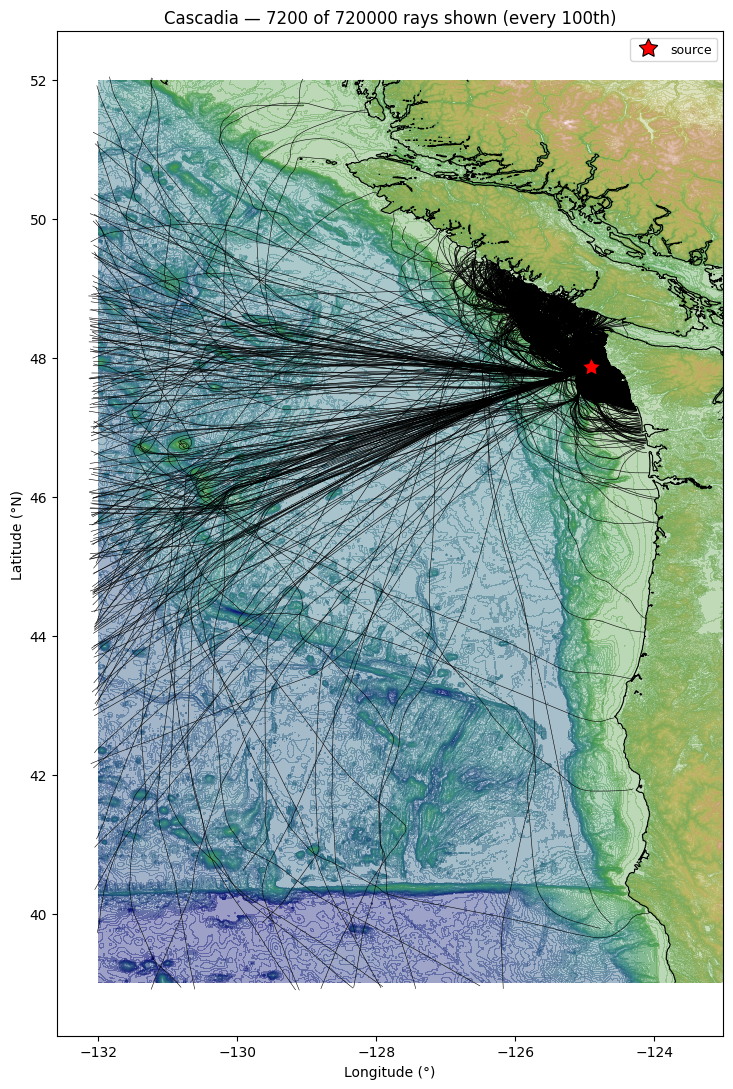

In [6]:
PLOT_EVERY_N = 100   # plot every Nth ray — increase to declutter, 1 = all rays

fig, ax = plt.subplots(figsize=(9, 11))

# Muted bathymetry background
ax.contourf(lon_full, lat_full, depth_grid,
            levels=200, cmap='gist_earth', norm=norm, alpha=0.4)
ax.contour(lon_full, lat_full, depth_grid,
           levels=[0], colors='k', linewidths=0.8)

# Ray paths (decimated)
for i in range(0, ray_lon.shape[0], PLOT_EVERY_N):
    ax.plot(ray_lon[i], ray_lat[i], color='black', linewidth=0.4, alpha=1)

# Source
ax.plot(SOURCE_LON, SOURCE_LAT,
        marker=(5, 1), markersize=14,
        markerfacecolor='red', markeredgecolor='k', markeredgewidth=0.8,
        linestyle='none', zorder=6, label='source')

ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°N)')
ax.set_title(
    f'Cascadia — {ray_lon.shape[0] // PLOT_EVERY_N} of {ray_lon.shape[0]} rays shown '
    f'(every {PLOT_EVERY_N}th)'
)
ax.set_aspect('equal')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

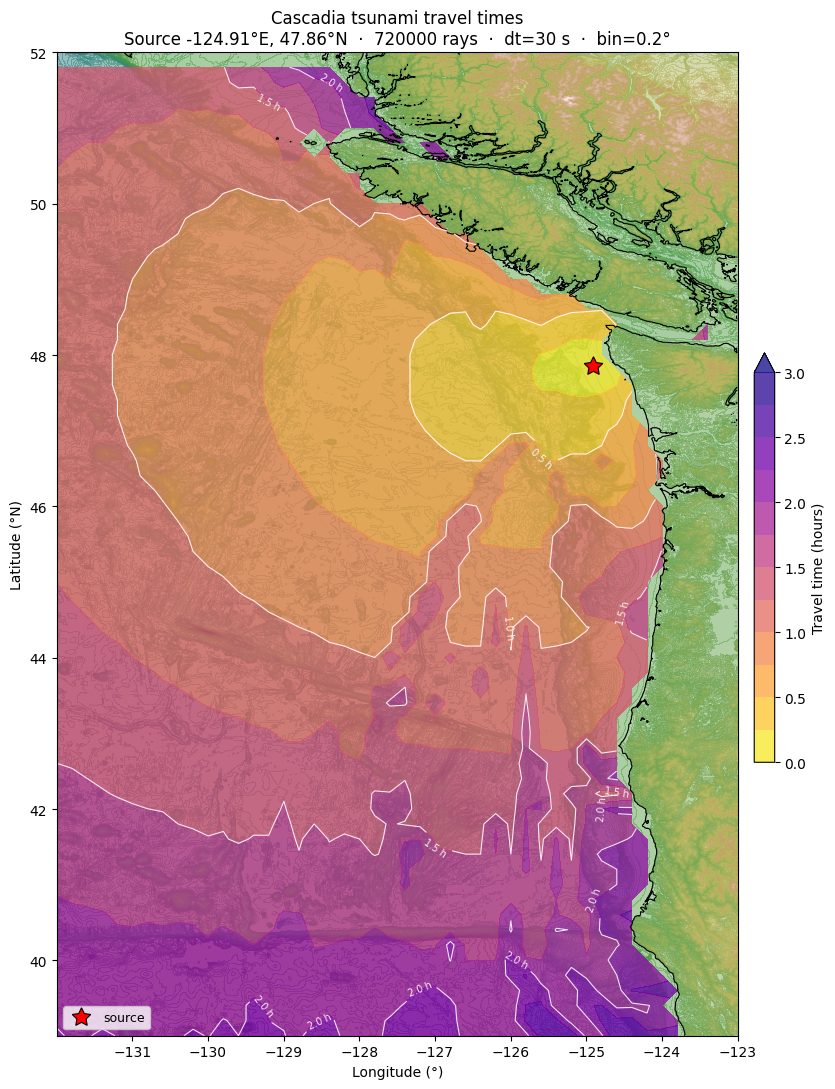

In [7]:
# ── figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 11))

# Full-resolution bathymetry background
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=max(vmax, 1))
ax.contourf(lon_full, lat_full, depth_grid,
            levels=200, cmap='gist_earth', norm=norm, alpha=0.5)
ax.contour(lon_full, lat_full, depth_grid,
           levels=[0], colors='k', linewidths=0.8)

# Travel time — filled contours on the coarser BIN_DEG grid
tt_max = MAX_TIME / 3600
cf = ax.contourf(lon_bin, lat_bin, travel_time,
                 levels=np.arange(0, tt_max + 0.25, 0.25),
                 cmap='plasma_r', alpha=0.75, extend='max')

# Isochrone lines every 30 minutes
cs = ax.contour(lon_bin, lat_bin, travel_time,
                levels=np.arange(0.5, tt_max + 0.5, 0.5),
                colors='white', linewidths=0.8, alpha=0.9)
ax.clabel(cs, fmt='%.1f h', fontsize=7, inline=True)

# Source
ax.plot(SOURCE_LON, SOURCE_LAT,
        marker=(5, 1), markersize=14,
        markerfacecolor='red', markeredgecolor='k', markeredgewidth=0.8,
        linestyle='none', zorder=6, label='source')

ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°N)')
ax.set_title(
    f'Cascadia tsunami travel times\n'
    f'Source {SOURCE_LON}°E, {SOURCE_LAT}°N  ·  '
    f'{len(AZIMUTHS_DEG)} rays  ·  dt={DT:.0f} s  ·  bin={BIN_DEG}°'
)
ax.set_aspect('equal')
ax.legend(fontsize=9, loc='lower left')

cbar = fig.colorbar(cf, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label('Travel time (hours)')
plt.tight_layout()
plt.show()